In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb


In [3]:
# Load the data
train = pd.read_csv('/content/transactions.csv')
test = pd.read_csv('/content/test.csv')
stores = pd.read_csv('/content/stores.csv')
oil = pd.read_csv('/content/oil.csv')
holidays_events = pd.read_csv('/content/holidays_events.csv')


In [4]:

# Convert 'date' columns to datetime format for all relevant datasets
train['date'] = pd.to_datetime(train['date'], errors='coerce')
test['date'] = pd.to_datetime(test['date'], errors='coerce')
oil['date'] = pd.to_datetime(oil['date'], errors='coerce')
holidays_events['date'] = pd.to_datetime(holidays_events['date'], errors='coerce')

# Ensure 'store_nbr' is an integer type in all relevant datasets
train['store_nbr'] = train['store_nbr'].astype(int)
test['store_nbr'] = test['store_nbr'].astype(int)
stores['store_nbr'] = stores['store_nbr'].astype(int)

# Fill missing values in the holidays_events data (forward fill)
holidays_events['is_holiday'] = 1
holidays_events['is_holiday'] = holidays_events['is_holiday'].astype(int)
holidays_events['is_holiday'] = holidays_events['is_holiday'].fillna(0)

# Merge holidays_events into train and test datasets
train = pd.merge(train, holidays_events[['date', 'is_holiday']], on='date', how='left')
test = pd.merge(test, holidays_events[['date', 'is_holiday']], on='date', how='left')

# Merge oil prices into train and test datasets
train = pd.merge(train, oil[['date', 'dcoilwtico']], on='date', how='left')
test = pd.merge(test, oil[['date', 'dcoilwtico']], on='date', how='left')

# Rename 'dcoilwtico' to 'oil_price' for consistency
train.rename(columns={'dcoilwtico': 'oil_price'}, inplace=True)
test.rename(columns={'dcoilwtico': 'oil_price'}, inplace=True)

# Merge stores metadata into train and test datasets
train = pd.merge(train, stores[['store_nbr', 'city', 'state', 'type']], on='store_nbr', how='left')
test = pd.merge(test, stores[['store_nbr', 'city', 'state', 'type']], on='store_nbr', how='left')

# Feature Engineering: Extract time-based features
train['day'] = train['date'].dt.day
train['week'] = train['date'].dt.isocalendar().week
train['month'] = train['date'].dt.month
train['year'] = train['date'].dt.year
train['day_of_week'] = train['date'].dt.dayofweek  # 0 = Monday, 6 = Sunday

test['day'] = test['date'].dt.day
test['week'] = test['date'].dt.isocalendar().week
test['month'] = test['date'].dt.month
test['year'] = test['date'].dt.year
test['day_of_week'] = test['date'].dt.dayofweek

# Fill missing holiday data (for days without events)
train['is_holiday'] = train['is_holiday'].fillna(0)
test['is_holiday'] = test['is_holiday'].fillna(0)

# Add lagged transactions features and rolling statistics
train['transactions_lag_1'] = train.groupby('store_nbr')['transactions'].shift(1)
train['transactions_lag_7'] = train.groupby('store_nbr')['transactions'].shift(7)
train['transactions_lag_30'] = train.groupby('store_nbr')['transactions'].shift(30)

# Create rolling means (7-day and 30-day moving averages) using 'transactions'
train['transactions_roll_7'] = train.groupby('store_nbr')['transactions'].rolling(7).mean().shift(1).reset_index(level=0, drop=True)
train['transactions_roll_30'] = train.groupby('store_nbr')['transactions'].rolling(30).mean().shift(1).reset_index(level=0, drop=True)

# Fill any missing values in the lagged and rolling features
train.fillna(0, inplace=True)

# Checking the final features in the train dataset
print(train.head())


        date  store_nbr  transactions  is_holiday  oil_price     city  \
0 2013-01-01         25           770         1.0       0.00  Salinas   
1 2013-01-02          1          2111         0.0      93.14    Quito   
2 2013-01-02          2          2358         0.0      93.14    Quito   
3 2013-01-02          3          3487         0.0      93.14    Quito   
4 2013-01-02          4          1922         0.0      93.14    Quito   

         state type  day  week  month  year  day_of_week  transactions_lag_1  \
0  Santa Elena    D    1     1      1  2013            1                 0.0   
1    Pichincha    D    2     1      1  2013            2                 0.0   
2    Pichincha    D    2     1      1  2013            2                 0.0   
3    Pichincha    D    2     1      1  2013            2                 0.0   
4    Pichincha    D    2     1      1  2013            2                 0.0   

   transactions_lag_7  transactions_lag_30  transactions_roll_7  \
0            

In [5]:
# from sklearn.model_selection import train_test_split

# Split the data into features (X) and target (y)
X = train.drop(['date', 'transactions'], axis=1)  # Remove date and target 'transactions'
y = train['transactions']  # Target variable

# Split into train and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape of the data
print(X_train.shape, X_val.shape)


(68005, 16) (17002, 16)


In [6]:
# Define the categorical columns
categorical_columns = ['city', 'state', 'type']

# Create a column transformer to apply OneHotEncoder to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_columns)  # OneHotEncode categorical columns
    ], remainder='passthrough'  # Leave the other columns unchanged
)

# Create a pipeline to first preprocess the data and then fit the model
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the validation set
y_pred_rf = rf_model.predict(X_val)

# Evaluate the model
rf_rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))
rf_mape = np.mean(np.abs((y_val - y_pred_rf) / y_val)) * 100

print(f"Random Forest RMSE: {rf_rmse}")
print(f"Random Forest MAPE: {rf_mape}")




Random Forest RMSE: 155.01340805877632
Random Forest MAPE: 7.048709643613754


In [7]:
# Repeat the same process for XGBoost model
xg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

# Train the model
xg_model.fit(X_train, y_train)

# Predict on the validation set
y_pred_xg = xg_model.predict(X_val)

# Evaluate the model
xg_rmse = np.sqrt(mean_squared_error(y_val, y_pred_xg))
xg_mape = np.mean(np.abs((y_val - y_pred_xg) / y_val)) * 100

print(f"XGBoost RMSE: {xg_rmse}")
print(f"XGBoost MAPE: {xg_mape}")

XGBoost RMSE: 150.90402061409762
XGBoost MAPE: 7.3836038395363985


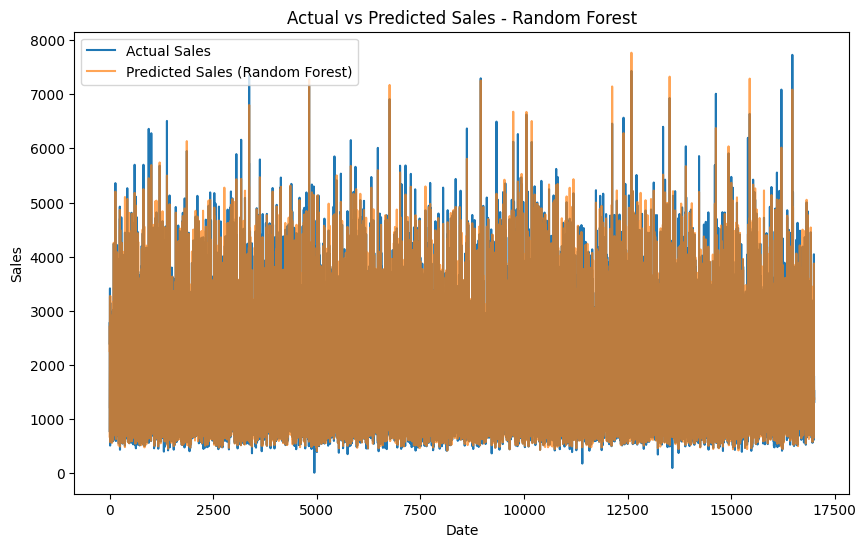

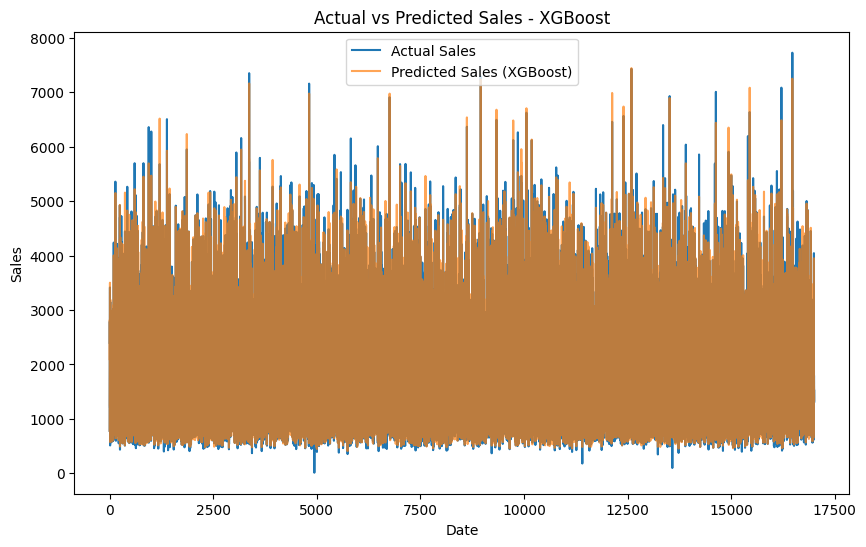

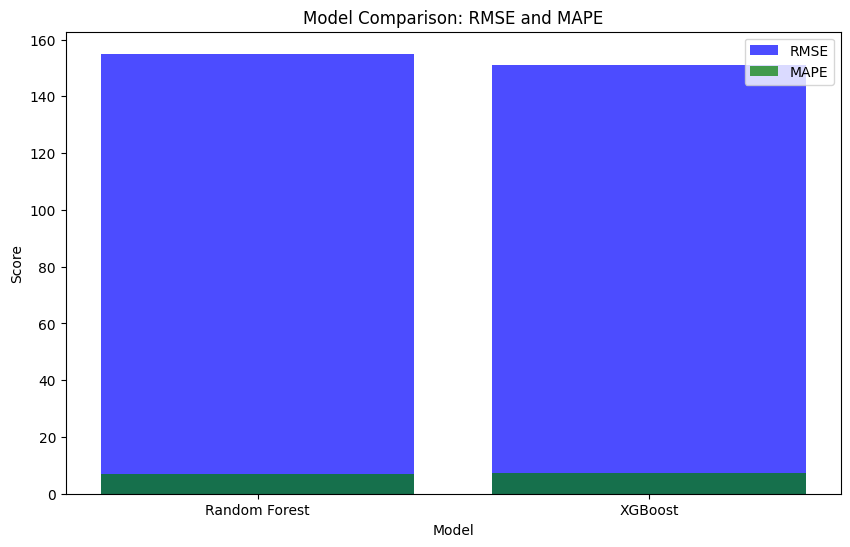

In [8]:
import matplotlib.pyplot as plt

# Plotting Actual vs Predicted for Random Forest
plt.figure(figsize=(10, 6))
plt.plot(y_val.values, label='Actual Sales')
plt.plot(y_pred_rf, label='Predicted Sales (Random Forest)', alpha=0.7)
plt.title('Actual vs Predicted Sales - Random Forest')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# Plotting Actual vs Predicted for XGBoost
plt.figure(figsize=(10, 6))
plt.plot(y_val.values, label='Actual Sales')
plt.plot(y_pred_xg, label='Predicted Sales (XGBoost)', alpha=0.7)
plt.title('Actual vs Predicted Sales - XGBoost')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# Compare the models using RMSE and MAPE
models = ['Random Forest', 'XGBoost']
rmse_scores = [rf_rmse, xg_rmse]
mape_scores = [rf_mape, xg_mape]

plt.figure(figsize=(10, 6))
plt.bar(models, rmse_scores, color='blue', alpha=0.7, label='RMSE')
plt.bar(models, mape_scores, color='green', alpha=0.7, label='MAPE')
plt.title('Model Comparison: RMSE and MAPE')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend()
plt.show()
